In [ ]:
from datetime import datetime, timedelta
import yfinance as yf
import pandas as pd
import time

start_date = (datetime.now() - timedelta(days=365*10+45)).strftime("%Y-%m-%d") # First date of last 12 month
# start_date = datetime(datetime.now().year, 1, 1).strftime("%Y-%m-%d") # First date of the start of this year
end_date = datetime.now().strftime("%Y-%m-%d")    # Current date

# Original funds dictionary
funds = {
    # Indexes 
    "NIFTY 50": "^NSEI",
    "BANK": "^NSEBANK",
    "FMCG": "^CNXFMCG",
    "PHARMA": "^CNXPHARMA",
    "IT": "^CNXIT",
    "INFRA": "^CNXINFRA",

    # Sector Funds
    "SBI Consumption Opportunities Fund Direct Growth": "0P0000XVJX.BO",
    "SBI Healthcare Opportunities Fund Direct Growth": "0P0000XVL7.BO",
    "SBI Banking & Financial Services Fund Direct Growth": "0P00015HLN.BO",
    "SBI Technology Opportunities Fund Direct Growth": "0P0000XVKP.BO",
    "SBI Infrastructure Fund Direct Growth": "0P0000XVJM.BO",

    # ELSS Funds 
    "HDFC ELSS TaxSaver Dir Gr": "0P0000XW8Z.BO",
    "SBI ELSS Tax Saver Dir Gr": "0P0000XVL9.BO",
    "Canara Robeco ELSS Tax Saver Dir Gr": "0P0000XW04.BO",
    "ICICI Pru ELSS Tax Saver Dir Gr": "0P0000XUZ4.BO"
}

def get_fund_category(ticker):
    """
    Get fund category from Yahoo Finance API
    """
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Check if it's an index (starts with ^)
        if ticker.startswith('^'):
            return "Index"
        
        # Try to get fund category from different info fields
        if 'category' in info:
            return info['category']
        elif 'fundFamily' in info:
            family = info.get('fundFamily', '').upper()
            if 'ELSS' in family or 'TAX' in family:
                return "ELSS"
            elif any(sector in family for sector in ['BANKING', 'PHARMA', 'IT', 'TECH', 'INFRA', 'CONSUMPTION', 'HEALTH']):
                return "Sector"
            else:
                return "Mutual Fund"
        elif 'quoteType' in info:
            quote_type = info['quoteType']
            if quote_type == 'MUTUALFUND':
                # Try to infer from fund name
                fund_name = info.get('longName', '').upper()
                if 'ELSS' in fund_name or 'TAX SAVER' in fund_name:
                    return "ELSS"
                elif any(sector in fund_name for sector in ['BANKING', 'PHARMA', 'IT', 'TECH', 'INFRA', 'CONSUMPTION', 'HEALTH']):
                    return "Sector"
                else:
                    return "Mutual Fund"
            elif quote_type == 'INDEX':
                return "Index"
        
        # Fallback: infer from ticker name or fund name
        fund_name_upper = list(funds.keys())[list(funds.values()).index(ticker)].upper()
        if 'ELSS' in fund_name_upper or 'TAX' in fund_name_upper:
            return "ELSS"
        elif any(sector in fund_name_upper for sector in ['BANKING', 'PHARMA', 'IT', 'TECH', 'INFRA', 'CONSUMPTION', 'HEALTH']):
            return "Sector"
        else:
            return "Unknown"
            
    except Exception as e:
        print(f"Error getting category for {ticker}: {e}")
        # Fallback to manual classification based on ticker
        if ticker.startswith('^'):
            return "Index"
        elif ticker.endswith('.BO'):
            fund_name = list(funds.keys())[list(funds.values()).index(ticker)].upper()
            if 'ELSS' in fund_name or 'TAX' in fund_name:
                return "ELSS"
            else:
                return "Sector"
        return "Unknown"

def get_additional_fund_info(ticker):
    """
    Get additional fund information like expense ratio, fund family, etc.
    """
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        additional_info = {
            'fund_family': info.get('fundFamily', 'N/A'),
            'expense_ratio': info.get('annualReportExpenseRatio', 'N/A'),
            'fund_type': info.get('quoteType', 'N/A'),
            'long_name': info.get('longName', 'N/A')
        }
        
        # Try to get fund-specific data if available
        try:
            fund_data = stock.funds_data
            if hasattr(fund_data, 'description'):
                additional_info['description'] = fund_data.description
        except:
            pass
            
        return additional_info
        
    except Exception as e:
        print(f"Error getting additional info for {ticker}: {e}")
        return {'fund_family': 'N/A', 'expense_ratio': 'N/A', 'fund_type': 'N/A', 'long_name': 'N/A'}

df_all = pd.DataFrame()

print("Fetching data and categories from Yahoo Finance...")
for fund_name, ticker in funds.items():
    try:
        print(f"Processing: {fund_name} ({ticker})")
        
        # Get category from Yahoo Finance
        category = get_fund_category(ticker)
        
        # Get additional fund information
        additional_info = get_additional_fund_info(ticker)
        
        # Fetch price data
        df = yf.download(tickers=ticker, start=start_date, end=end_date, progress=False)
        df.columns = df.columns.droplevel(1)  # Remove ticker level
        df = df.reset_index()
        
        # Add fund information columns
        df.insert(0, 'Fund_Name', fund_name)
        df.insert(1, 'Ticker', ticker)
        df.insert(2, 'Category', category)
        df.insert(3, 'Fund_Family', additional_info['fund_family'])
        df.insert(4, 'Expense_Ratio', additional_info['expense_ratio'])
        df.insert(5, 'Fund_Type', additional_info['fund_type'])
        df.insert(6, 'Long_Name', additional_info['long_name'])
        
        df_all = pd.concat([df_all, df], axis=0)
        
        # Small delay to avoid overwhelming the API
        time.sleep(0.5)
        
    except Exception as e:
        print(f"Error fetching data for {fund_name} ({ticker}): {e}")
        continue

# Save to CSV
df_all.to_csv('mutual_funds_nav.csv', index=False)

print(f"\nData saved to 'mutual_funds_nav.csv'")
print(f"Total records: {len(df_all)}")
print(f"Date range: {start_date} to {end_date}")



Current date and time: 2025-07-26
2024-07-26


In [ ]:
from nsepython import *

# Get quote data for ITC
itc_quote = nse_eq("ITC")

# Print full data (optional)
print(itc_quote)

# Extract current market price
current_price = itc_quote['priceInfo']['lastPrice']

print(f"Current stock price of ITC: ₹{current_price}")


{'info': {'symbol': 'ITC', 'companyName': 'ITC Limited', 'industry': 'Diversified FMCG', 'activeSeries': ['EQ', 'T0'], 'debtSeries': [], 'isFNOSec': True, 'isCASec': False, 'isSLBSec': True, 'isDebtSec': False, 'isSuspended': False, 'tempSuspendedSeries': [], 'isETFSec': False, 'isDelisted': False, 'isin': 'INE154A01025', 'slb_isin': 'INE154A01025', 'listingDate': '1995-08-23', 'isMunicipalBond': False, 'isHybridSymbol': False, 'isTop10': False, 'identifier': 'ITCEQN'}, 'metadata': {'series': 'EQ', 'symbol': 'ITC', 'isin': 'INE154A01025', 'status': 'Listed', 'listingDate': '23-Aug-1995', 'industry': 'Diversified FMCG', 'lastUpdateTime': '25-Jul-2025 16:00:00', 'pdSectorPe': 25.53, 'pdSymbolPe': 25.53, 'pdSectorInd': 'NIFTY 50', 'pdSectorIndAll': ['NIFTY 50', 'NIFTY TOP 20 EQUAL WEIGHT', 'NIFTY 500', 'NIFTY INDIA CONSUMPTION', 'NIFTY 200', 'NIFTY50 VALUE 20', 'NIFTY DIVIDEND OPPORTUNITIES 50', 'NIFTY100 QUALITY 30', 'NIFTY LOW VOLATILITY 50', 'NIFTY100 EQUAL WEIGHT', 'NIFTY100 LOW VOLAT

In [ ]:
import os
import json
import logging
import pandas as pd
from datetime import datetime, timedelta
from dotenv import load_dotenv
import time

# Import functions from your modules
from modules import (
    get_last_date_for_fund,
    save_master_data_to_db,
    save_nav_data_to_db,
    get_fund_info,
    get_price_data,
    delete_records_from_date,
    calculate_and_save_trends
)

# Load environment variables from .env file
load_dotenv()

# --- Configuration and Class Setup -------------------------------------------

class FundCollector:
    """
    Orchestrates the process of fetching and storing fund data.
    """
    def __init__(self):
        # Load configurations from .env
        self.db_path: str = os.getenv("DB_PATH", "db/eqt.db")
        # Updated table names
        self.master_table_name: str = os.getenv("MF_TABLE_NAME", "mf")
        self.nav_table_name: str = os.getenv("NAV_TABLE_NAME", "mf_nav")
        self.trends_table_name: str = os.getenv("TRENDS_TABLE_NAME", "mf_nav_trends")
        self.log_path: str = os.getenv("LOG_PATH", "logs/app.log")
        # Correcting the file path based on user input
        self.funds_file_path: str = os.getenv("FUNDS_FILE_PATH", "mutual_funds.json")

        # Derived configurations
        self.start_date: str = self._get_full_history_start_date()
        self.end_date: str = datetime.now().strftime("%Y-%m-%d")
        
        # Setup logging first so other methods can use it
        self._setup_logging()

        # Load funds after logging is set up
        self.funds: dict = self._load_funds_from_json(self.funds_file_path)

    def _setup_logging(self):
        """Configures the logging for the application."""
        log_directory = os.path.dirname(self.log_path)
        os.makedirs(log_directory, exist_ok=True)
        
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
            handlers=[
                logging.FileHandler(self.log_path),
                logging.StreamHandler()
            ]
        )
        self.logger = logging.getLogger(__name__)

    def _get_full_history_start_date(self) -> str:
        """Calculates the start date for full history pull based on .env values."""
        years = int(os.getenv("START_DATE_YEARS", "10"))
        days = int(os.getenv("START_DATE_DAYS", "45"))
        return (datetime.now() - timedelta(days=365 * years + days)).strftime("%Y-%m-%d")

    def _load_funds_from_json(self, file_path: str) -> dict:
        """Loads fund data from a JSON file, with a check for file existence."""
        if not os.path.exists(file_path):
            self.logger.error(f"Funds JSON file not found at {file_path}")
            return {}
        try:
            with open(file_path, 'r') as f:
                return json.load(f)
        except (FileNotFoundError, json.JSONDecodeError) as e:
            self.logger.error(f"Error loading funds JSON from {file_path}: {e}")
            return {}

    def run(self) -> None:
        """Main orchestration method to fetch and save fund data."""
        db_directory = os.path.dirname(self.db_path)
        os.makedirs(db_directory, exist_ok=True)
        
        # New lists to hold the separated dataframes
        all_master_data_to_save: list[pd.DataFrame] = []
        all_nav_data_to_save: list[pd.DataFrame] = []

        self.logger.info("Starting data collection process...")
        
        for category, funds_dict in self.funds.items():
            self.logger.info(f"--- Processing Category: {category} ---")
            for fund_name, ticker in funds_dict.items():
                self.logger.info(f"Processing: {fund_name} ({ticker})")
                
                # We now check against the new NAV table
                last_date = get_last_date_for_fund(ticker, self.db_path, self.nav_table_name)
                
                if last_date:
                    fetch_start_date = pd.to_datetime(last_date).strftime("%Y-%m-%d")
                    if fetch_start_date >= self.end_date:
                        self.logger.info("  Data is up to date, skipping.")
                        continue
                    
                    self.logger.info(f"  Last data: {last_date}, fetching from: {fetch_start_date}")
                    # Delete data from the last recorded date onwards to prepare for fresh data
                    delete_records_from_date(ticker, fetch_start_date, self.db_path, self.nav_table_name)
                else:
                    fetch_start_date = self.start_date
                    self.logger.info(f"  No existing data, fetching full history from: {fetch_start_date}")

                fund_info = get_fund_info(ticker)
                price_data = get_price_data(ticker, fetch_start_date, self.end_date)
                
                # Prepare and append the master data
                master_data = {
                    'Fund_Name': [fund_name],
                    'Ticker': [ticker],
                    'Category': [category],
                    **{key: [value] for key, value in fund_info.items() if key not in ['Expense_Ratio', 'Net_Assets', 'PE_Ratio', 'Holdings']}
                }
                master_df = pd.DataFrame(master_data)
                all_master_data_to_save.append(master_df)

                if not price_data.empty:
                    # Prepare and append the NAV data
                    # Removed 'Adj_Close' as it's not present when auto_adjust is True
                    nav_data_columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume']
                    nav_df = price_data[nav_data_columns].copy()
                    nav_df['Ticker'] = ticker
                    nav_df['Fund_Name'] = fund_name
                    nav_df['Category'] = category
                    all_nav_data_to_save.append(nav_df)
                    
                # time.sleep(0.5) # Uncomment to prevent API rate limiting

        # Define columns for empty dataframes to prevent syntax errors on first run
        master_cols = ['Fund_Name', 'Ticker', 'Category', 'Fund_Family', 'Long_Name', 'Fund_Type', 'Currency',
                       'Market_Cap', 'NAV', 'Fund_Manager', 'Management_Company', 'Inception_Date', 'Yield',
                       'Beta', 'Investment_Strategy', 'Category_Name', 'Fund_Description']
        nav_cols = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Ticker', 'Fund_Name', 'Category']

        # Always create the master table, even if empty
        final_master_df = pd.concat(all_master_data_to_save, ignore_index=True) if all_master_data_to_save else pd.DataFrame(columns=master_cols)
        save_master_data_to_db(final_master_df, self.db_path, self.master_table_name)

        # Always create the NAV table, even if empty
        final_nav_df = pd.concat(all_nav_data_to_save, ignore_index=True) if all_nav_data_to_save else pd.DataFrame(columns=nav_cols)
        save_nav_data_to_db(final_nav_df, self.db_path, self.nav_table_name)
        
        self.logger.info("Starting trends calculation...")
        calculate_and_save_trends(self.db_path, self.nav_table_name, self.master_table_name, self.trends_table_name)
        self.logger.info("Data collection and trends calculation complete.")

if __name__ == '__main__':
    collector = FundCollector()
    collector.run()


C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_27068\2304554211.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_27068\2304554211.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_27068\2304554211.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\T

In [ ]:
from datetime import datetime, timedelta
import yfinance as yf
import pandas as pd

start_date = (datetime.now() - timedelta(days=365+90)).strftime("%Y-%m-%d") # First date of last 12 month
# start_date = datetime(datetime.now().year, 1, 1).strftime("%Y-%m-%d") # First date of the start of this year
end_date = datetime.now().strftime("%Y-%m-%d")    # Current date



indices = {
    "NIFTY 50": "^NSEI",           # NIFTY 50 Index (this one was correct)
    "BANK": "^NSEBANK",            # NIFTY Bank Index (this one was correct)
    "FMCG": "^CNXFMCG",            # NIFTY FMCG Index - CORRECTED
    "PHARMA": "^CNXPHARMA",        # NIFTY Pharma Index - CORRECTED  
    "IT": "^CNXIT",                # NIFTY IT Index - CORRECTED
    "INFRA": "^CNXINFRA"           # NIFTY Infrastructure Index - CORRECTED
}

df_all = pd.DataFrame()

try:
    for index, ticker in indices.items():
        df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
        df.columns = df.columns.droplevel(1)  # Remove ticker level
        df = df.reset_index()
        df.insert(0, 'Index', index)   # Insert 'Index' as the first column
        df.insert(1, 'Ticker', ticker) # Insert 'Ticker' as the second column
        df_all = pd.concat([df_all, df], axis=0) # Concatenate dataframes
except Exception as e:
    print(f"Error fetching data for {index} ({ticker}): {e}")

df_all.to_csv('nifty_thematic_indices.csv',index=False)  # Save the combined dataframe to a CSV file


C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_38224\609859273.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_38224\609859273.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_38224\609859273.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, start=start_date, end=end_date) # Fetch data for each index
[*********************100%***********************]  1 of 1 completed
C:\Users\nagarjuna.bandi\AppData\Local\Temp

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df_ravg = pd.read_csv('mutual_funds_nav.csv')


# Convert Date column to datetime
df_ravg['Date'] = pd.to_datetime(df_ravg['Date']).dt.date

# Sort by Index and Date to ensure proper order
df_ravg = df_ravg.sort_values(['Index', 'Date']).reset_index(drop=True)



# Apply rolling average to each index group
df_ravg['Rolling_3M_Avg'] = df_ravg.groupby('Index')['Close'].transform(
    lambda x: x.rolling(window=90, min_periods=30, center=True).mean()
)

# Function to get the base value from the nearest date
def get_base_value_from_nearest_date(group, start_date, column_name):
    filtered = group[group['Date'] >= start_date]
    if not filtered.empty:
        return filtered.iloc[0][column_name]
    else:
        return np.nan

start_date_10y = (datetime.now() - timedelta(days=365*10)).date()
start_date_5y = (datetime.now() - timedelta(days=365*5)).date()
start_date_3y = (datetime.now() - timedelta(days=365*3)).date()
start_date_1y = (datetime.now() - timedelta(days=365)).date()
start_date_6m = (datetime.now() - timedelta(days=180)).date()
start_date_3m = (datetime.now() - timedelta(days=90)).date()
start_date_ytd = datetime(datetime.now().year, 1, 1).date()

# Get the base value per Index group
base_10y_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_10y, 'Close'))
base_10y_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_10y, 'Rolling_3M_Avg'))

base_5y_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_5y, 'Close'))
base_5y_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_5y, 'Rolling_3M_Avg'))

base_3y_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_3y, 'Close'))
base_3y_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_3y, 'Rolling_3M_Avg'))

base_1y_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_1y, 'Close'))
base_1y_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_1y, 'Rolling_3M_Avg'))

base_6m_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_6m, 'Close'))
base_6m_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_6m, 'Rolling_3M_Avg'))

base_3m_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_3m, 'Close'))
base_3m_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_3m, 'Rolling_3M_Avg'))

base_ytd_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_ytd, 'Close'))
base_ytd_rolling_3m_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_ytd, 'Rolling_3M_Avg'))

# Map back to the main DataFrame
df_ravg['Base_10Y_Close'] = df_ravg['Index'].map(base_10y_close_values)
df_ravg['Base_10Y_Rolling_3M'] = df_ravg['Index'].map(base_10y_rolling_3m_values)

df_ravg['Base_5Y_Close'] = df_ravg['Index'].map(base_5y_close_values)
df_ravg['Base_5Y_Rolling_3M'] = df_ravg['Index'].map(base_5y_rolling_3m_values)

df_ravg['Base_3Y_Close'] = df_ravg['Index'].map(base_3y_close_values)
df_ravg['Base_3Y_Rolling_3M'] = df_ravg['Index'].map(base_3y_rolling_3m_values)

df_ravg['Base_1Y_Close'] = df_ravg['Index'].map(base_1y_close_values)
df_ravg['Base_1Y_Rolling_3M'] = df_ravg['Index'].map(base_1y_rolling_3m_values)

df_ravg['Base_6M_Close'] = df_ravg['Index'].map(base_6m_close_values)
df_ravg['Base_6M_Rolling_3M'] = df_ravg['Index'].map(base_6m_rolling_3m_values)

df_ravg['Base_3M_Close'] = df_ravg['Index'].map(base_3m_close_values)
df_ravg['Base_3M_Rolling_3M'] = df_ravg['Index'].map(base_3m_rolling_3m_values)

df_ravg['Base_YTD_Close'] = df_ravg['Index'].map(base_ytd_close_values)
df_ravg['Base_YTD_Rolling_3M'] = df_ravg['Index'].map(base_ytd_rolling_3m_values)

# Calculate percentage changes
df_ravg['Close_10Y_Pct'] = ((df_ravg['Close'] - df_ravg['Base_10Y_Close']) / df_ravg['Base_10Y_Close']) * 100
df_ravg['Rolling_3M_Avg_10Y_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_10Y_Rolling_3M']) / df_ravg['Base_10Y_Rolling_3M']) * 100

df_ravg['Close_5Y_Pct'] = ((df_ravg['Close'] - df_ravg['Base_5Y_Close']) / df_ravg['Base_5Y_Close']) * 100
df_ravg['Rolling_3M_Avg_5Y_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_5Y_Rolling_3M']) / df_ravg['Base_5Y_Rolling_3M']) * 100

df_ravg['Close_3Y_Pct'] = ((df_ravg['Close'] - df_ravg['Base_3Y_Close']) / df_ravg['Base_3Y_Close']) * 100
df_ravg['Rolling_3M_Avg_3Y_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_3Y_Rolling_3M']) / df_ravg['Base_3Y_Rolling_3M']) * 100

df_ravg['Close_1Y_Pct'] = ((df_ravg['Close'] - df_ravg['Base_1Y_Close']) / df_ravg['Base_1Y_Close']) * 100
df_ravg['Rolling_3M_Avg_1Y_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_1Y_Rolling_3M']) / df_ravg['Base_1Y_Rolling_3M']) * 100

df_ravg['Close_6M_Pct'] = ((df_ravg['Close'] - df_ravg['Base_6M_Close']) / df_ravg['Base_6M_Close']) * 100
df_ravg['Rolling_3M_Avg_6M_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_6M_Rolling_3M']) / df_ravg['Base_6M_Rolling_3M']) * 100

df_ravg['Close_3M_Pct'] = ((df_ravg['Close'] - df_ravg['Base_3M_Close']) / df_ravg['Base_3M_Close']) * 100
df_ravg['Rolling_3M_Avg_3M_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_3M_Rolling_3M']) / df_ravg['Base_3M_Rolling_3M']) * 100

df_ravg['Close_YTD_Pct'] = ((df_ravg['Close'] - df_ravg['Base_YTD_Close']) / df_ravg['Base_YTD_Close']) * 100
df_ravg['Rolling_3M_Avg_YTD_Pct'] = ((df_ravg['Rolling_3M_Avg'] - df_ravg['Base_YTD_Rolling_3M']) / df_ravg['Base_YTD_Rolling_3M']) * 100


df_ravg.to_csv('mutual_funds_nav_trends.csv',index=False)  # Save the combined dataframe to a CSV file

C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_27068\930934124.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base_10y_close_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date_10y, 'Close'))
C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_27068\930934124.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base_10y_rolling_3m_values = df_ravg.groupby('I

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta


# Read the CSV file
df_ravg = pd.read_csv('nifty_thematic_indices.csv')

start_date = datetime.now() - timedelta(days=365)

# Convert Date column to datetime
df_ravg['Date'] = pd.to_datetime(df_ravg['Date'])

# Sort by Index and Date to ensure proper order
df_ravg = df_ravg.sort_values(['Index', 'Date']).reset_index(drop=True)

print("METHOD: Vectorized Rolling 3-Month Average Calculation")
print("="*60)

# Calculate rolling 3-month average for all indices at once using groupby
rolling_window = 90  # 3 months ≈ 90 days

def get_base_value_from_nearest_date(group, start_date):
    filtered = group[group['Date'] >= start_date]
    if not filtered.empty:
        return filtered.iloc[0]['Close']
    else:
        return np.nan

# Apply rolling average to each index group
df_ravg['Rolling_Avg'] = df_ravg.groupby('Index')['Close'].transform(
    lambda x: x.rolling(window=rolling_window, min_periods=30, center=True).mean()
)

# Get the base value per Index group
base_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date))

# Map those base values back to the original dataframe
df_ravg['Base_Close'] = df_ravg['Index'].map(base_values)

# Calculate percentage change outside the function
df_ravg['Close_Pct'] = ((df_ravg['Close'] - df_ravg['Base_Close']) / df_ravg['Base_Close']) * 100


# Calculate percentage change from the first value of each index's close price
# df_ravg['Close_Pct'] = df_ravg.groupby('Index')['Close'].transform(
#     lambda x: ((x - x.iloc[0]) / x.iloc[0]) * 100
# )




# Use Rolling_Avg itself as the baseline for percentage calculation
# Calculate percentage change from the first value of each index's rolling average
df_ravg['Rolling_Avg_Pct'] = df_ravg.groupby('Index')['Rolling_Avg'].transform(
    lambda x: ((x - x.iloc[0]) / x.iloc[0]) * 100
)

df_ravg.to_csv('nifty_thematic_indices_ravg.csv',index=False)  # Save the combined dataframe to a CSV file

METHOD: Vectorized Rolling 3-Month Average Calculation


C:\Users\nagarjuna.bandi\AppData\Local\Temp\ipykernel_38224\1854810473.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base_values = df_ravg.groupby('Index').apply(lambda g: get_base_value_from_nearest_date(g, start_date))


In [92]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"  # forces it to open in your web browser

# Read the CSV file
df = pd.read_csv('sbi_thematic_funds_ravg.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date']).dt.date

start_date = (datetime.now() - timedelta(days=365)).date()

df = df[df['Date'] >= start_date]  # Filter data for the last 12 months

# Plotly Express Line Chart
fig = px.line(
    df,
    x='Date',
    y='Rolling_3M_Avg_1Y_Pct',
    color='Index',
    markers=True,
    title='12-Month Rolling Average Performance of SBI Thematic Funds',
    labels={
        'Date': 'Date',
        'Rolling_3M_Avg_1Y_Pct': 'Rolling Avg %',
        'Index': 'Fund Name'
    }
)

# Add horizontal zero line
fig.add_hline(y=0, line_dash="dash", line_color="gray")

# Improve layout
fig.update_layout(
    template="plotly_white",
    title_font_size=18,
    legend_title_text='Funds',
    legend=dict(x=0.01, y=0.99),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

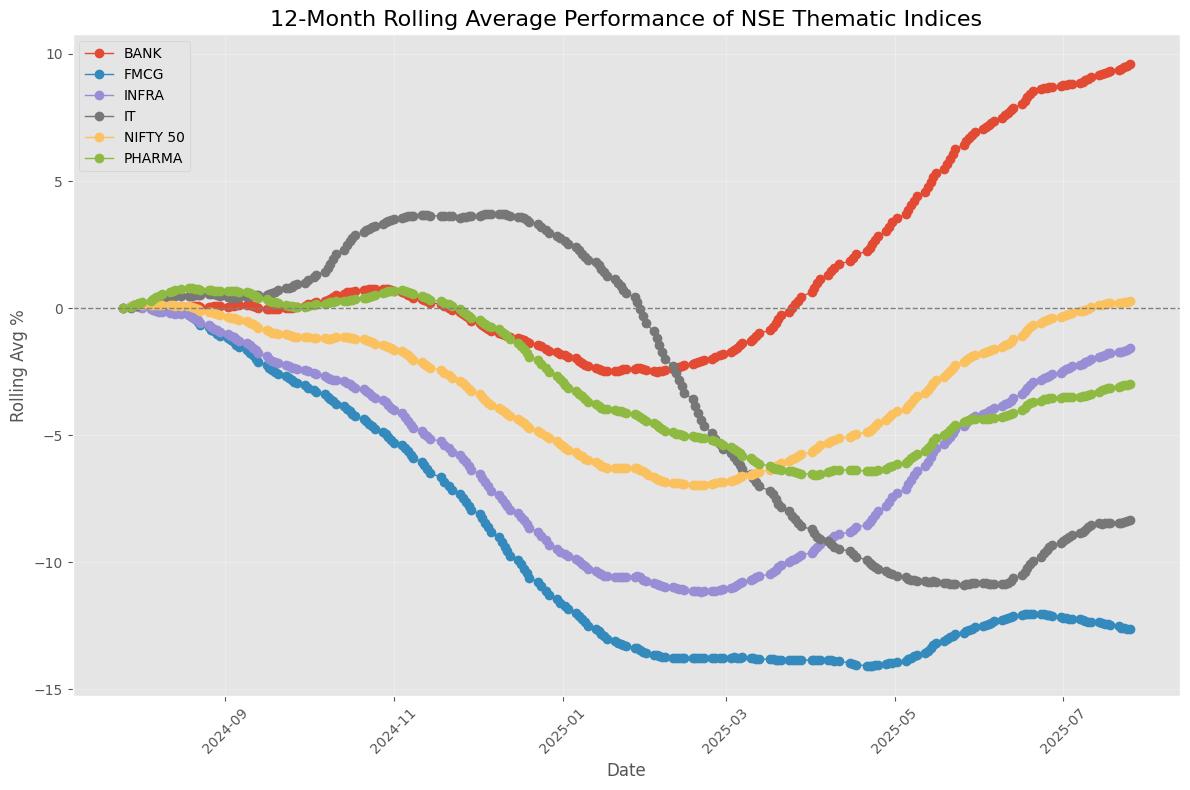

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('nifty_thematic_indices_ravg.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each index
for index_name in df['Index'].unique():
    index_data = df[df['Index'] == index_name] 
    plt.plot(index_data['Date'], index_data['Rolling_Avg_Pct'], marker='o', label=index_name, linewidth=1)

# Customize the plot
plt.title("12-Month Rolling Average Performance of NSE Thematic Indices", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Rolling Avg %")
plt.legend(loc="upper left", fontsize=10)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

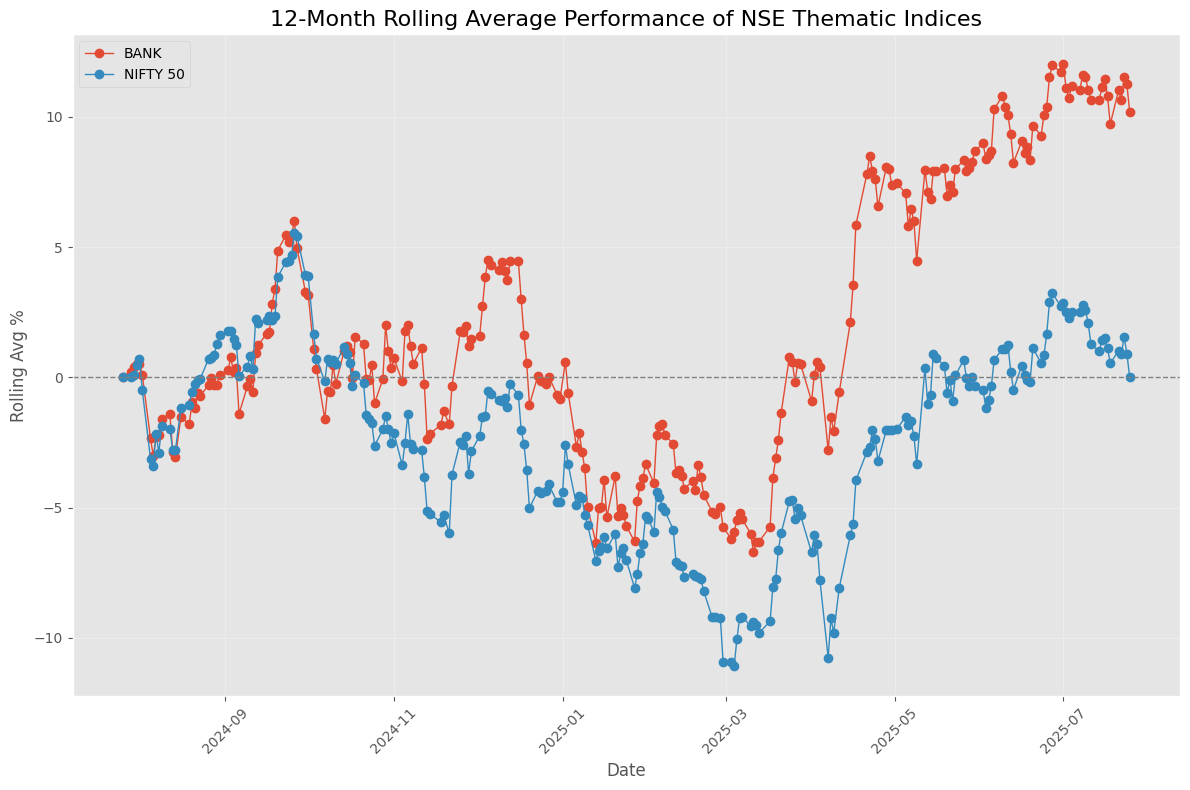

<Figure size 640x480 with 0 Axes>

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('nifty_thematic_indices_ravg.csv')

df = df[df['Index'].isin(["NIFTY 50", "BANK"])]


# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each index
for index_name in df['Index'].unique():
    index_data = df[df['Index'] == index_name] 
    plt.plot(index_data['Date'], index_data['Close_Pct'], marker='o', label=index_name, linewidth=1)

# Customize the plot
plt.title("12-Month Rolling Average Performance of NSE Thematic Indices", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Rolling Avg %")
plt.legend(loc="upper left", fontsize=10)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

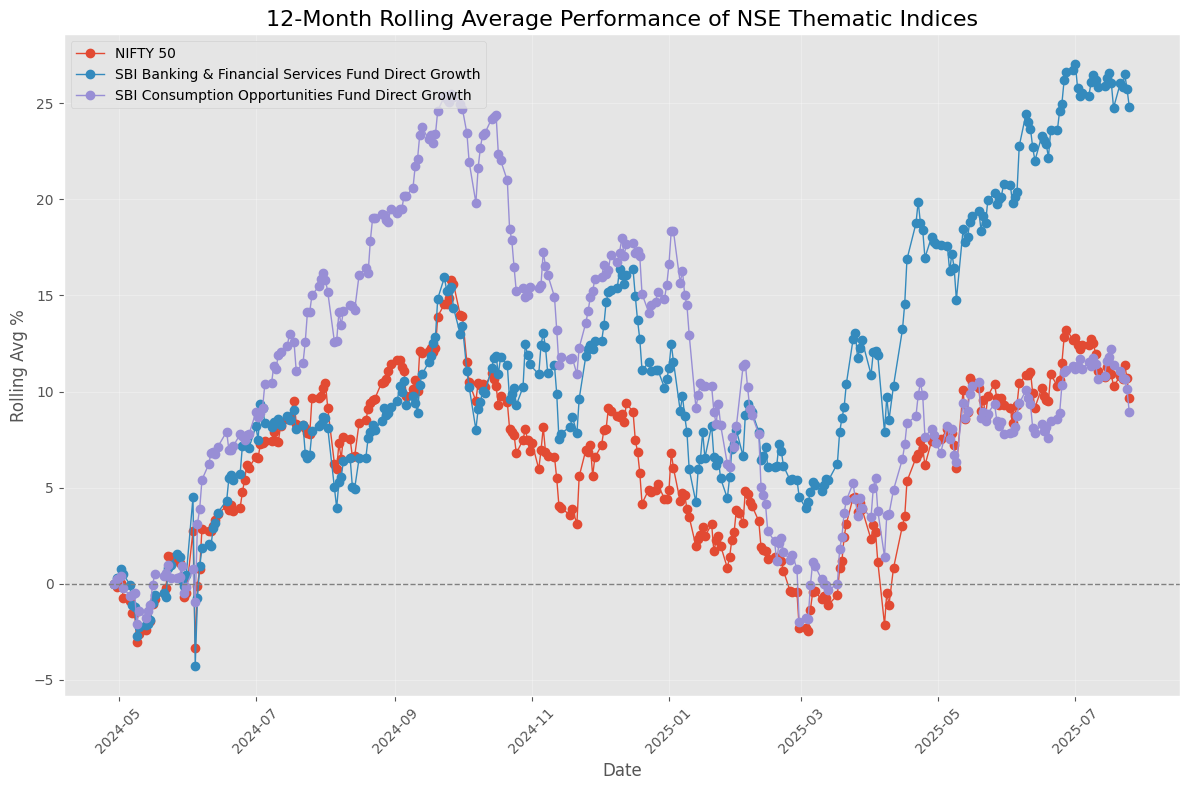

<Figure size 640x480 with 0 Axes>

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('sbi_thematic_funds_ravg.csv')

df = df[df['Index'].isin(["NIFTY 50", "SBI Consumption Opportunities Fund Direct Growth","SBI Banking & Financial Services Fund Direct Growth"])]


# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each index
for index_name in df['Index'].unique():
    index_data = df[df['Index'] == index_name] 
    plt.plot(index_data['Date'], index_data['Close_Pct'], marker='o', label=index_name, linewidth=1)

# Customize the plot
plt.title("12-Month Rolling Average Performance of NSE Thematic Indices", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Rolling Avg %")
plt.legend(loc="upper left", fontsize=10)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show the plot
plt.tight_layout()
plt.show()